**Super Store_Exploratory_Data_Analysis(EDA)**

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


Load the Dataset (Taken From Kaggle)

In [2]:
# Load the CSV file
file_path = "SampleSuperstore.csv"   # <-- change this path if needed
df = pd.read_csv(file_path)

# Quick look at the first few rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
# Shape of the dataset (rows, columns)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names and data types
df.info()

Dataset shape: 9994 rows, 13 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


Data CLeaning

In [4]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

Missing values per column:
No missing values found.

Number of duplicate rows: 17


In [5]:
# Remove exact duplicate rows (keep the first occurrence)
# We keep a copy of the original row count for comparison
rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print(f"Removed {rows_before - rows_after} duplicate rows.")
print(f"Dataset now has {rows_after} rows.")


Removed 17 duplicate rows.
Dataset now has 9977 rows.


Summary

describe() : gives stastical orientation of every coloumn

In [6]:
# this only for numaric coloumns
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [7]:
# Summary categorical columns
df.describe(include="object")

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9977,9977,9977,9977,9977,9977,9977,9977
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5955,5183,9977,914,1996,3193,6012,1522


Correlation HeatMap

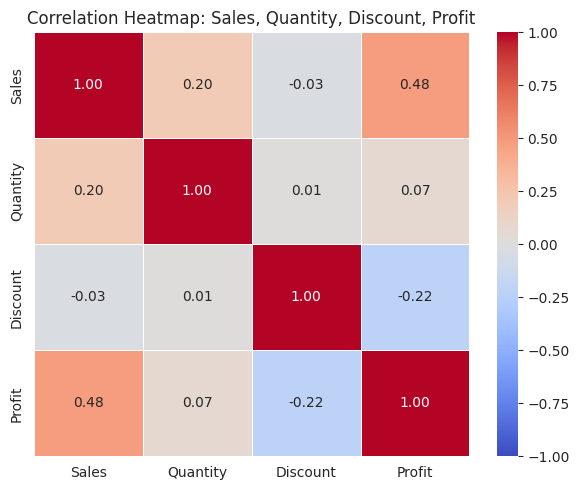

In [8]:
# Select numeric columns relevant to the business question
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Sales, Quantity, Discount, Profit")
plt.tight_layout()
plt.show()

Distribution of Sales(Histogram)

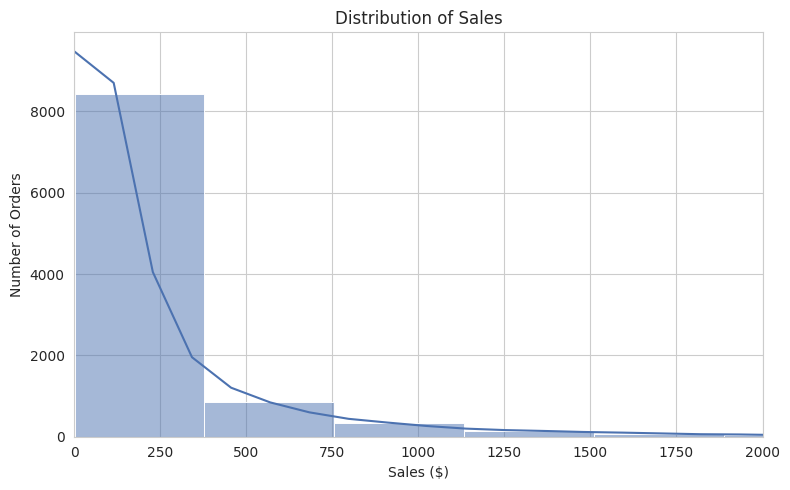

Sales skewness: 12.96


In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=60, kde=True, color="#4C72B0")
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.xlim(0, 2000)   # zoom in on the bulk of the data (a few extreme outliers exist beyond this)
plt.tight_layout()
plt.show()

print("Sales skewness:", round(df["Sales"].skew(), 2))

Profit Outliers By Category (Box Plot)

/tmp/ipykernel_3397/4209941444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit", palette="Set2")


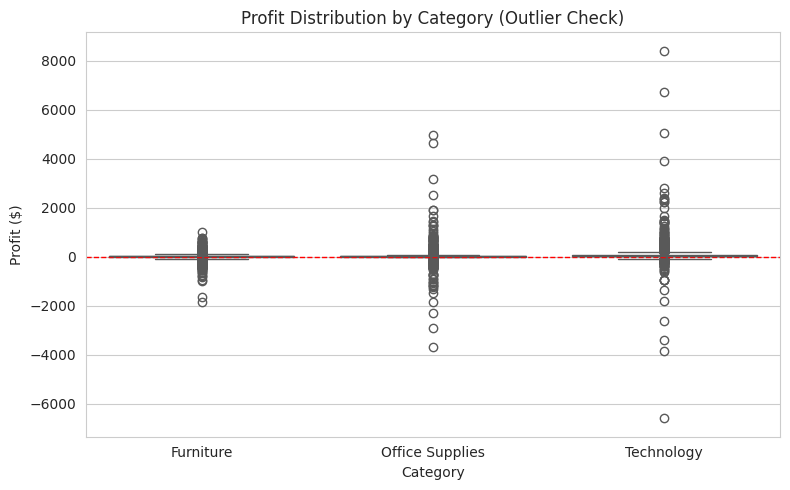

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Category", y="Profit", palette="Set2")
plt.title("Profit Distribution by Category (Outlier Check)")
plt.ylabel("Profit ($)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)  # break-even line
plt.tight_layout()
plt.show()


Total Profit by Sub Category (BAR CHART)

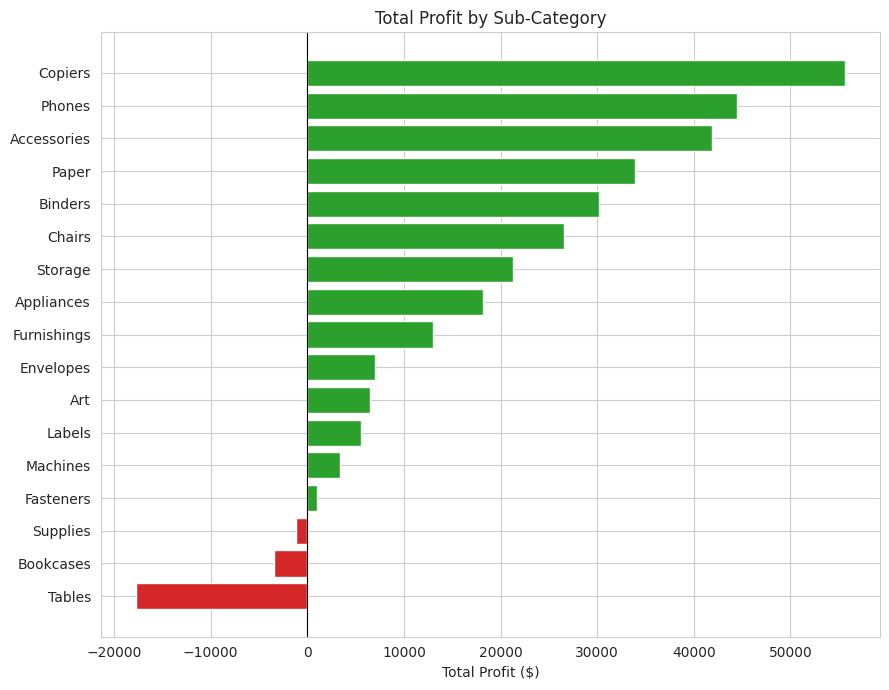

In [11]:
profit_by_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(9, 7))
colors = ["#d62728" if val < 0 else "#2ca02c" for val in profit_by_subcat.values]
plt.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors)
plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit ($)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Discount Vs Profit (Scatter Plot)

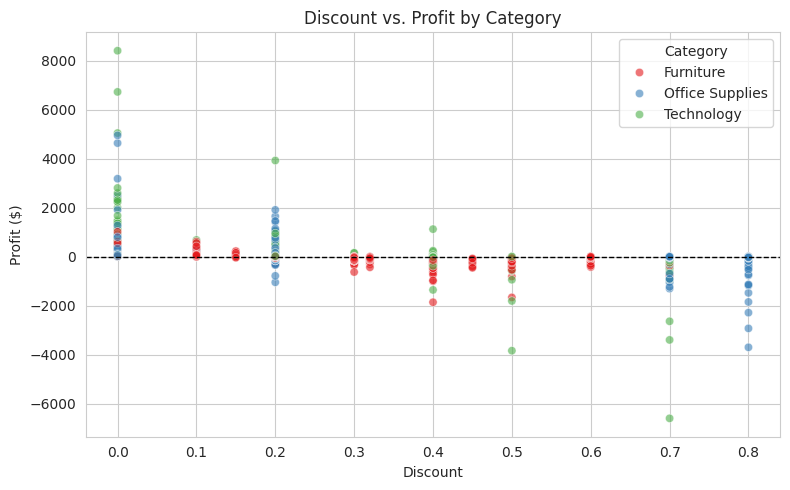

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.6, palette="Set1")
plt.title("Discount vs. Profit by Category")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

Sales vs Profit By Region (Grouped Bar Chart)

               Sales       Profit  Profit Margin %
Region                                            
West     725255.6365  108329.8079            14.94
East     678435.1960   91506.3092            13.49
Central  500782.8528   39655.8752             7.92
South    391721.9050   46749.4303            11.93


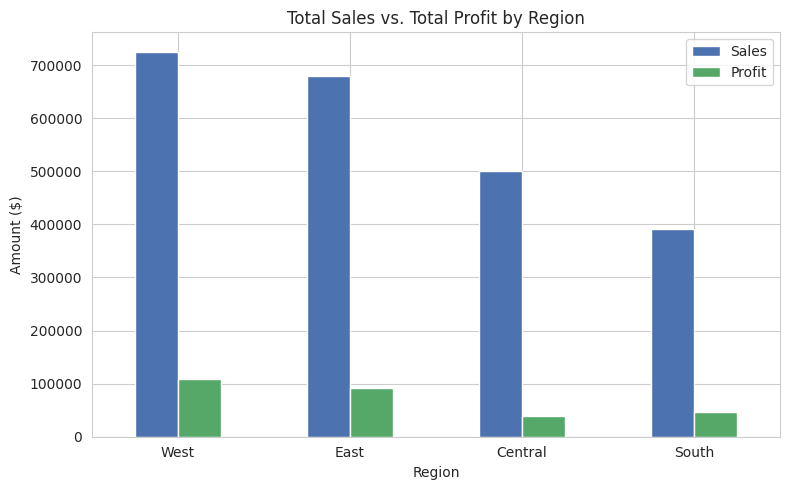

In [13]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
region_summary_pct = region_summary.copy()
region_summary_pct["Profit Margin %"] = (region_summary["Profit"] / region_summary["Sales"] * 100).round(2)
print(region_summary_pct)

region_summary.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#55A868"])
plt.title("Total Sales vs. Total Profit by Region")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Profit Trend across Discount Bands (LINE Chart)

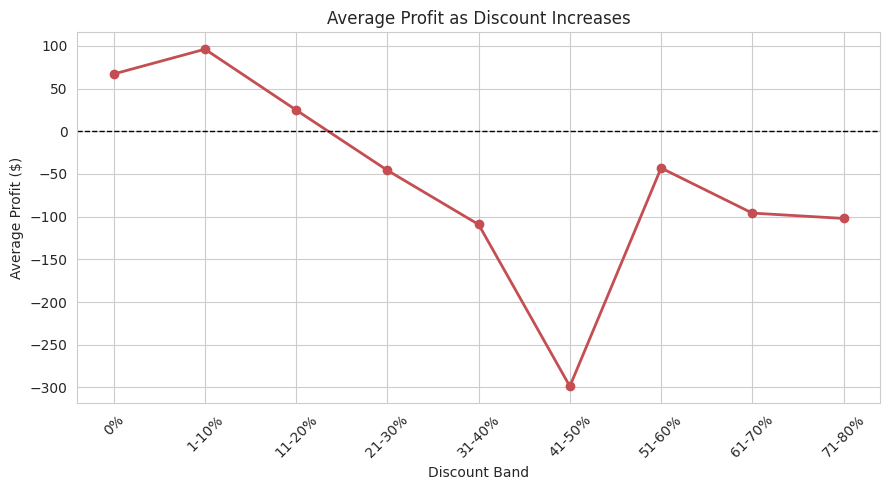

In [14]:
# Create discount bins (bands) and compute average profit per band
bins = [-0.01, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
labels = ["0%", "1-10%", "11-20%", "21-30%", "31-40%", "41-50%", "51-60%", "61-70%", "71-80%"]
df["Discount Band"] = pd.cut(df["Discount"], bins=bins, labels=labels)

trend = df.groupby("Discount Band", observed=True)["Profit"].mean()

plt.figure(figsize=(9, 5))
plt.plot(trend.index.astype(str), trend.values, marker="o", color="#C44E52", linewidth=2)
plt.title("Average Profit as Discount Increases")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit ($)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()